In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import make_blobs

In [2]:
def log_gaussian_pdf(X, mean, cov):
    """
    Compute the log of the multivariate Gaussian density for each point in X.

    Parameters
    ----------
    X : array of shape (N, d)
        N data points in d-dimensional space.
    mean : array of shape (d,)
        Mean of the Gaussian.
    cov : array of shape (d, d)
        Covariance matrix of the Gaussian (assumed invertible).

    Returns
    -------
    log_probs : array of shape (N,)
        log of N( x_i | mean, cov ) for each i.
    """
    d = X.shape[1]
    # Compute determinant and inverse
    cov_inv = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    # Center the data
    X_centered = X - mean  # shape (N, d)

    # Mahalanobis distance
    mahal = np.einsum('ij,jk,ik->i', X_centered, cov_inv, X_centered)

    # Normalization constant
    # log( (2*pi)^{-d/2} * det_cov^{-1/2} * exp(-0.5 * mahal) )
    # = -0.5 * [ d*log(2*pi) + log(det_cov) + mahal ]
    const = -0.5 * (d * np.log(2 * np.pi) + np.log(det_cov))
    log_probs = const - 0.5 * mahal

    return log_probs

def gmm_em(X, K, max_iter=100, tol=1e-6, verbose=False, random_state=42):
    """
    Perform EM algorithm for a Gaussian Mixture Model (GMM).

    Parameters
    ----------
    X : array of shape (N, d)
        The dataset of N points in d dimensions.
    K : int
        Number of mixture components.
    max_iter : int, optional
        Maximum number of EM iterations.
    tol : float, optional
        Convergence tolerance based on change in log-likelihood.
    verbose : bool, optional
        If True, print log-likelihood progress.
    random_state : int, optional
        Seed for reproducible random initialization.

    Returns
    -------
    pi : array of shape (K,)
        The fitted mixture weights (sum to 1).
    means : array of shape (K, d)
        The fitted means for each component.
    covs : array of shape (K, d, d)
        The fitted covariance matrices for each component.
    resp : array of shape (N, K)
        The final responsibilities (posterior probabilities).
    log_likelihoods : list of floats
        The log-likelihood at each iteration.
    """
    np.random.seed(random_state)

    N, d = X.shape

    # 1) Initialize parameters randomly
    # Initialize means by sampling K random points from X
    indices = np.random.choice(N, K, replace=False)
    means = X[indices].copy()

    # Initialize covariance matrices to identity
    covs = np.array([np.eye(d) for _ in range(K)])

    # Initialize mixture weights to uniform
    pi = np.ones(K) / K

    # For tracking convergence
    log_likelihoods = []

    for iteration in range(max_iter):
        # ---------- E-step: compute responsibilities ----------
        # resp[n, k] = pi[k] * N(x_n | means[k], covs[k])
        # but we do it in log space for numerical stability.

        # log_resp will store log( pi_k * N(x_i | mu_k, Sigma_k) )
        log_resp = np.zeros((N, K))

        for k in range(K):
            # log pi_k + log Gaussian(x_i | mu_k, cov_k)
            log_resp[:, k] = np.log(pi[k]) + log_gaussian_pdf(X, means[k], covs[k])

        # To get responsibilities, we exponentiate after normalizing
        # but let's do log-sum-exp for numerical stability
        log_sum_exp = np.logaddexp.reduce(log_resp, axis=1)  # shape (N,)

        # log_resp - log_sum_exp gives log of "posterior" for each component
        resp = np.exp(log_resp - log_sum_exp[:, np.newaxis])  # shape (N, K)

        # Compute log-likelihood = sum_i log( sum_k pi_k * N(...) )
        log_likelihood = np.sum(log_sum_exp)
        log_likelihoods.append(log_likelihood)

        if verbose:
            print(f"Iteration {iteration}, log-likelihood = {log_likelihood:.6f}")

        # Check for convergence
        if iteration > 0:
            if np.abs(log_likelihood - log_likelihoods[-2]) < tol:
                if verbose:
                    print("Converged at iteration", iteration)
                break

        # ---------- M-step: update parameters ----------
        # "effective number" of points assigned to each cluster k
        Nk = resp.sum(axis=0)  # shape (K,)

        # Update pi (mixing weights)
        pi = Nk / N

        # Update means
        means = (resp.T @ X) / Nk[:, np.newaxis]

        # Update covariances
        for k in range(K):
            X_centered = X - means[k]
            # Weighted sum of outer products
            covs[k] = (resp[:, k, np.newaxis] * X_centered).T @ X_centered / Nk[k]

            # For numerical stability, you might add a tiny diagonal jitter
            # covs[k] += 1e-6 * np.eye(d)

    # Return final parameters and responsibilities
    return pi, means, covs, resp, log_likelihoods





In [3]:
def gmm_em_weighted(X, sample_weights, K, max_iter=100, tol=1e-6,
                    verbose=False, random_state=42):
    """
    EM algorithm for fitting a Gaussian Mixture Model (GMM) with sample weights.

    Parameters
    ----------
    X : ndarray of shape (N, d)
        Data points.
    sample_weights : ndarray of shape (N,)
        Nonnegative weights for each sample. (If you allow negative,
        you lose the standard probabilistic interpretation.)
    K : int
        Number of mixture components.
    max_iter : int
        Maximum number of EM iterations.
    tol : float
        Convergence tolerance on log-likelihood change.
    verbose : bool
        If True, prints iteration logs.
    random_state : int
        For reproducible random initialization.

    Returns
    -------
    pi : ndarray of shape (K,)
        Mixture weights (sum to 1).
    means : ndarray of shape (K, d)
        Estimated means for each Gaussian component.
    covs : ndarray of shape (K, d, d)
        Estimated covariance matrices.
    resp : ndarray of shape (N, K)
        Final responsibilities (posterior probabilities).
    log_likelihoods : list of float
        Log-likelihood at each iteration.
    """
    np.random.seed(random_state)
    N, d = X.shape

    # If user doesn't supply weights, default to uniform weights = 1
    if sample_weights is None:
        sample_weights = np.ones(N)

    # 1) Initialize parameters
    indices = np.random.choice(N, K, replace=False)
    means = X[indices].copy()              # shape (K, d)
    covs = np.array([np.eye(d) for _ in range(K)])  # shape (K, d, d)
    pi = np.ones(K) / K

    # For monitoring convergence
    log_likelihoods = []

    for iteration in range(max_iter):
        # ---------- E-step: compute responsibilities (unweighted) ----------
        # log_resp[n, k] = log(pi_k) + log( N(x_n | mean_k, cov_k) )
        log_resp = np.zeros((N, K))
        for k in range(K):
            log_resp[:, k] = np.log(pi[k]) + log_gaussian_pdf(X, means[k], covs[k])

        # We do a log-sum-exp trick for numerical stability
        log_sum_exp = np.logaddexp.reduce(log_resp, axis=1)  # shape (N,)

        # Convert to actual responsibilities
        # resp[n, k] = exp(log_resp[n, k] - log_sum_exp[n])
        resp = np.exp(log_resp - log_sum_exp[:, np.newaxis])

        # ---------- Weighted log-likelihood ----------
        # L = sum_i w_i * log( sum_k pi_k * N(x_i | mu_k, cov_k) )
        log_likelihood = np.sum(sample_weights * log_sum_exp)
        log_likelihoods.append(log_likelihood)

        if verbose:
            print(f"Iteration {iteration}, log-likelihood = {log_likelihood:.6f}")

        # Check convergence
        if iteration > 0:
            if np.abs(log_likelihood - log_likelihoods[-2]) < tol:
                if verbose:
                    print("Converged at iteration", iteration)
                break

        # ---------- M-step: incorporate sample weights ----------

        # Weighted responsibilities: w_i * resp[i, k]
        # shape (N, K)
        weighted_resp = sample_weights[:, np.newaxis] * resp

        # Effective counts for each component k
        Nk = np.sum(weighted_resp, axis=0)  # shape (K,)

        # Update mixture proportions
        # pi_k = (1 / sum_i w_i) * sum_i ( w_i * gamma_{ik} )
        # so we divide by total weight, not by N
        total_weight = np.sum(sample_weights)
        pi = Nk / total_weight

        # Update means
        # mu_k = (1 / Nk) * sum_i [ w_i * gamma_{ik} * x_i ]
        means = (weighted_resp.T @ X) / Nk[:, np.newaxis]

        # Update covariances
        for k in range(K):
            X_centered = X - means[k]
            cov_k = (weighted_resp[:, k, np.newaxis] * X_centered).T @ X_centered
            cov_k /= Nk[k]
            # regularize for numerical stability
            cov_k += 1e-6 * np.eye(d)
            covs[k] = cov_k

    return pi, means, covs, resp, log_likelihoods

In [4]:
def plot_ellipse(mean, cov, ax, color='black', alpha=1.0):
    """
    Plot an ellipse corresponding to the 2D covariance 'cov' centered at 'mean'.
    We draw the ellipse for 2 standard deviations along each principal axis.
    """
    # Eigen-decomposition to find principal axes
    vals, vecs = np.linalg.eigh(cov)

    # Sort eigenvalues in descending order (for consistent orientation)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Angle of the ellipse
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # 2 standard deviations = 2 sqrt(eigenvalue)
    width, height = 2 * 2 * np.sqrt(vals)  # factor of 2 for "2 std dev"

    # Create the ellipse patch
    ell = Ellipse(xy=mean,
                  width=width,
                  height=height,
                  angle=theta,
                  edgecolor=color,
                  facecolor='none',
                  lw=2,
                  alpha=alpha)
    ax.add_patch(ell)

In [5]:
# ------------------ Example usage ------------------

# Generate synthetic data (2D for simplicity here).
# np.random.seed(0)

# We'll make a mixture of two Gaussians in 2D
d = 2
N = 400
K = 4
# x1 = np.random.normal(loc=-2.0, scale=0.5, size=(N//2, d))
# x2 = np.random.normal(loc=2.0, scale=1.0, size=(N//2, d))
# X = np.vstack([x1, x2])

X = make_blobs(
    n_samples=N,
    centers=K+1,
    random_state=np.random.choice(100000),
)[0]

# Shuffle data
np.random.shuffle(X)

weights = np.ones(X.shape[0]) / X.shape[0]
weights[0] *= N



In [6]:
# Fit GMM with K=2
# pi, means, covs, resp, log_likelihoods = gmm_em(X, K=K, max_iter=50, tol=1e-5, verbose=True)
pi, means, covs, resp, log_likelihoods = gmm_em_weighted(X, weights, K=K, max_iter=50, tol=1e-5, verbose=True)


print("\nFinal mixture weights:", pi)
print("Final means:", means)
print("Final covariances:", covs)
print("Final log-likelihood:", log_likelihoods[-1])

Iteration 0, log-likelihood = -21.797780
Iteration 1, log-likelihood = -7.563205
Iteration 2, log-likelihood = -6.368434
Iteration 3, log-likelihood = -6.077895
Iteration 4, log-likelihood = -5.534225
Iteration 5, log-likelihood = -4.408671
Iteration 6, log-likelihood = -1.696066
Iteration 7, log-likelihood = 3.296659
Iteration 8, log-likelihood = 5.458851
Iteration 9, log-likelihood = 5.489551
Iteration 10, log-likelihood = 5.524050
Iteration 11, log-likelihood = 5.544100
Iteration 12, log-likelihood = 5.547332
Iteration 13, log-likelihood = 5.548966
Iteration 14, log-likelihood = 5.550950
Iteration 15, log-likelihood = 5.554537
Iteration 16, log-likelihood = 5.562552
Iteration 17, log-likelihood = 5.583955
Iteration 18, log-likelihood = 5.640528
Iteration 19, log-likelihood = 5.677466
Iteration 20, log-likelihood = 5.677497
Iteration 21, log-likelihood = 5.677497
Converged at iteration 21

Final mixture weights: [0.20024297 0.20033147 0.09879986 0.50062569]
Final means: [[ 2.57080504

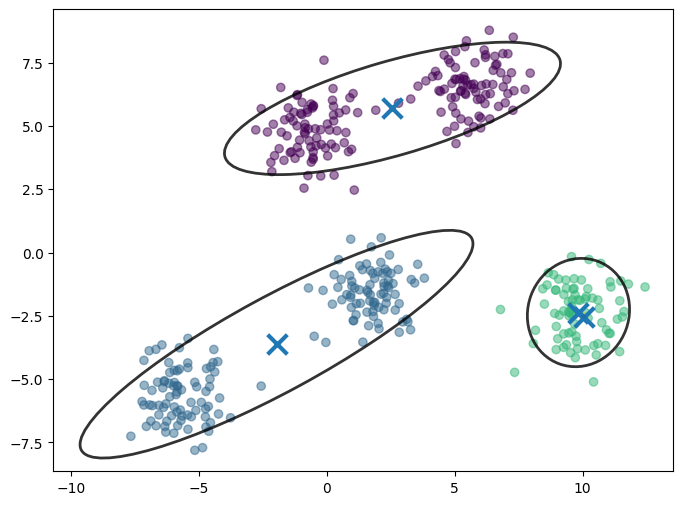

In [7]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X[:, 0], X[:, 1], c=resp.argmax(axis=1), cmap='viridis', alpha=0.5)
ax.scatter(means[:, 0], means[:, 1], marker='x', s=200, linewidths=3)

for k in range(K):
    plot_ellipse(
        means[k],
        covs[k],
        ax,
        # color=colors[k],
        alpha=0.8
    )

Iteration 0, log-likelihood = -5039.108399
Iteration 1, log-likelihood = -2456.697030
Iteration 2, log-likelihood = -2388.907782
Iteration 3, log-likelihood = -2356.200719
Iteration 4, log-likelihood = -2318.432642
Iteration 5, log-likelihood = -2261.100390
Iteration 6, log-likelihood = -2193.076145
Iteration 7, log-likelihood = -2165.190255
Iteration 8, log-likelihood = -2164.302962
Iteration 9, log-likelihood = -2164.290376
Iteration 10, log-likelihood = -2164.288878
Iteration 11, log-likelihood = -2164.288675
Iteration 12, log-likelihood = -2164.288648
Iteration 13, log-likelihood = -2164.288644
Converged at iteration 13

Final mixture weights: [0.33276639 0.33369871 0.3335349 ]
Final means:
 [[-2.01523009  4.95014357]
 [ 2.90469703  4.09558838]
 [-0.1015893   0.01009951]]
Final covariances:
 [[[ 0.52827774  0.03208846]
  [ 0.03208846  0.64135347]]

 [[ 1.02286015 -0.39034485]
  [-0.39034485  0.94016385]]

 [[ 1.18322611  0.43481524]
  [ 0.43481524  0.6197409 ]]]
Final log-likelihoo

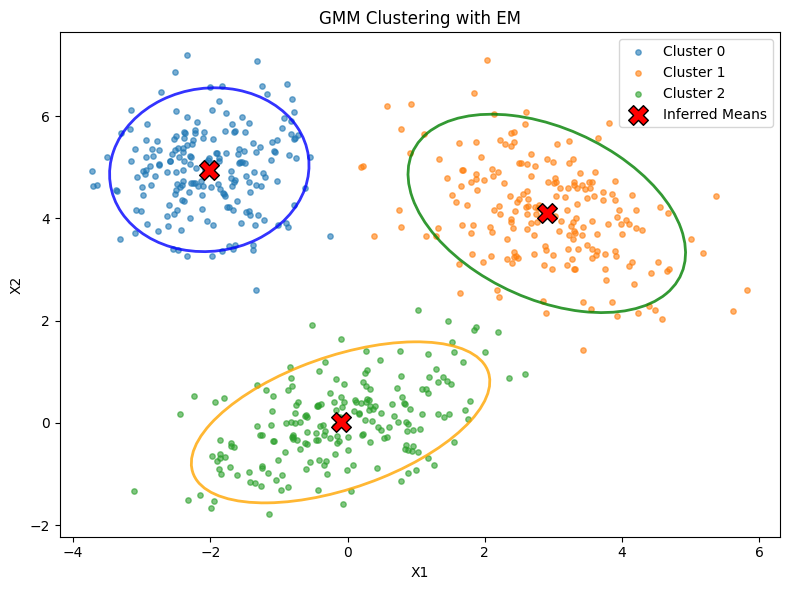

In [8]:
# ------------------ Generate synthetic 2D data ------------------
# np.random.seed(0)
N = 600

# Mixture of three Gaussians in 2D
# Component 1
mean1 = np.array([0, 0])
cov1 = np.array([[1.0, 0.3], [0.3, 0.5]])
X1 = np.random.multivariate_normal(mean1, cov1, size=(N//3))

# Component 2
mean2 = np.array([3, 4])
cov2 = np.array([[1.0, -0.4], [-0.4, 1.0]])
X2 = np.random.multivariate_normal(mean2, cov2, size=(N//3))

# Component 3
mean3 = np.array([-2, 5])
cov3 = np.array([[0.5, 0], [0, 0.5]])
X3 = np.random.multivariate_normal(mean3, cov3, size=(N//3))

X = np.vstack([X1, X2, X3])
np.random.shuffle(X)

# ------------------ Fit GMM (K=3) ------------------
K = 3
pi, means, covs, resp, log_likelihoods = gmm_em(
    X,
    K=K,
    max_iter=100,
    tol=1e-5,
    verbose=True
)
print("\nFinal mixture weights:", pi)
print("Final means:\n", means)
print("Final covariances:\n", covs)
print("Final log-likelihood:", log_likelihoods[-1])

# ------------------ Plot results ------------------
# Assign each point to the cluster with highest posterior probability
cluster_assignments = np.argmax(resp, axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of points colored by cluster
for k in range(K):
    cluster_pts = X[cluster_assignments == k]
    ax.scatter(cluster_pts[:, 0], cluster_pts[:, 1],
                s=15, alpha=0.6, label=f'Cluster {k}')

# Plot the inferred means
ax.scatter(means[:, 0], means[:, 1],
            s=200, c='red', marker='X', edgecolor='black', label='Inferred Means')

# Draw ellipses for each covariance
colors = ['blue', 'green', 'orange']  # choose any set of K colors
for k in range(K):
    plot_ellipse(means[k], covs[k], ax, color=colors[k], alpha=0.8)

ax.set_title("GMM Clustering with EM")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## EM With Negative Points that "push" probability

In [9]:
import numpy as np
from numpy.linalg import inv, det

def log_gaussian_pdf(X, mean, cov):
    """
    Compute the log of the multivariate Gaussian density for each point in X.
    X : shape (N, d)
    mean : shape (d,)
    cov : shape (d, d)
    Return : array of shape (N,)
        The log-pdf for each row in X.
    """
    d = X.shape[1]
    cov_inv = inv(cov)
    cov_det = det(cov)

    X_centered = X - mean
    # Mahalanobis distance: (x - mu)^T Sigma^{-1} (x - mu)
    mahal = np.einsum('ij,jk,ik->i', X_centered, cov_inv, X_centered)

    # log of the (multivariate) Gaussian
    # = -0.5 * [d*log(2*pi) + log(det(Sigma)) + mahal]
    const = -0.5 * (d * np.log(2. * np.pi) + np.log(cov_det))
    return const - 0.5 * mahal

def e_step_responsibilities(X, pi, means, covs):
    """
    Compute standard (positive) responsibilities for data X.
    X : shape (N, d)
    pi : shape (K,)
    means : shape (K, d)
    covs : shape (K, d, d)

    Returns:
    --------
    resp : shape (N, K)
       resp[i, k] = posterior prob that x_i is in cluster k
    """
    N, d = X.shape
    K = len(pi)
    log_resp = np.zeros((N, K))

    # Compute log(pi_k * N(x|mu_k,cov_k)) for each k
    for k in range(K):
        log_resp[:, k] = np.log(pi[k]) + log_gaussian_pdf(X, means[k], covs[k])

    # Use log-sum-exp to convert these to responsibilities
    logsumexp = np.logaddexp.reduce(log_resp, axis=1)  # shape (N,)
    resp = np.exp(log_resp - logsumexp[:, np.newaxis]) # shape (N, K)
    return resp

def gmm_em_with_negatives(X_pos, X_neg, K, beta=1.0,
                          max_iter=100, tol=1e-6, verbose=False, random_state=42):
    """
    EM for GMM with "negative" data that repels the distribution.

    Parameters
    ----------
    X_pos : ndarray of shape (N_pos, d)
        Positive observations (attract the mixture).
    X_neg : ndarray of shape (N_neg, d)
        Negative observations (repel the mixture).
    K : int
        Number of mixture components.
    beta : float
        Repulsion strength.  beta >= 0
    max_iter : int
        Maximum number of EM iterations.
    tol : float
        Convergence threshold on the difference in the objective.
    verbose : bool
        If True, prints debugging info each iteration.
    random_state : int
        For reproducibility.

    Returns
    -------
    pi : shape (K,)
        The learned mixture weights.
    means : shape (K, d)
        Learned means.
    covs : shape (K, d, d)
        Learned covariances.
    resp_pos : shape (N_pos, K)
        Final responsibilities for positive points.
    resp_neg : shape (N_neg, K)
        Final responsibilities for negative points.
    log_likelihoods : list of float
        The penalized log-likelihood at each iteration.
    """
    np.random.seed(random_state)
    N_pos, d = X_pos.shape
    N_neg = X_neg.shape[0]

    # 1) Initialize parameters
    # Pick K distinct points from X_pos for means
    init_idx = np.random.choice(N_pos, K, replace=False)
    means = X_pos[init_idx].copy()             # shape (K, d)
    covs = np.array([np.eye(d) for _ in range(K)])  # shape (K, d, d)
    pi = np.ones(K) / K

    # Preallocate space
    log_likelihoods = []

    # For the denominator in M-step for means/covs
    def safe_denom(x):
        # Avoid dividing by zero if repulsion is large
        return x if np.abs(x) > 1e-12 else 1e-12

    # ---------- EM loop ----------
    for iteration in range(max_iter):
        # ---------- E-step ----------
        # Positive responsibilities
        resp_pos = e_step_responsibilities(X_pos, pi, means, covs)  # (N_pos, K)
        # Negative responsibilities
        resp_neg = e_step_responsibilities(X_neg, pi, means, covs)  # (N_neg, K)

        # ---------- Compute penalized objective (log-likelihood) ----------
        #   L = sum_{i in pos} log( sum_k pi_k * N(x_i|...) )
        #     - beta * sum_{j in neg} log( sum_k pi_k * N(x_j|...) )
        # We'll reuse the logs from the e_step_responsibilities computations:
        # but let's just recompute directly for clarity.

        # log sum_k pi_k N(x_i), for pos
        log_resp_pos = np.zeros((N_pos, K))
        for k in range(K):
            log_resp_pos[:, k] = np.log(pi[k]) + log_gaussian_pdf(X_pos, means[k], covs[k])
        # log-sum-exp over k
        log_sum_pos = np.logaddexp.reduce(log_resp_pos, axis=1)

        # log sum_k pi_k N(x_j), for neg
        log_resp_neg = np.zeros((N_neg, K))
        for k in range(K):
            log_resp_neg[:, k] = np.log(pi[k]) + log_gaussian_pdf(X_neg, means[k], covs[k])
        log_sum_neg = np.logaddexp.reduce(log_resp_neg, axis=1)

        log_likelihood = np.sum(log_sum_pos) - beta * np.sum(log_sum_neg)
        log_likelihoods.append(log_likelihood)

        if verbose:
            print(f"Iteration {iteration:2d}, Penalized LL = {log_likelihood:.6f}")

        # ---------- Check for convergence ----------
        if iteration > 0:
            if np.abs(log_likelihood - log_likelihoods[-2]) < tol:
                if verbose:
                    print(f"Converged at iteration {iteration}")
                break

        # ---------- M-step ----------
        # Following the user's formula for means:
        #   mu_k_new = [ sum_i (gamma_pos[i,k]*x_i) - beta * sum_j(gamma_neg[j,k]* x_neg_j ) ]
        #              / [ sum_i gamma_pos[i,k]     - beta * sum_j gamma_neg[j,k] ]
        #
        # Similarly for mixture weights and covariances.

        # Effective counts
        N_k_pos = resp_pos.sum(axis=0)  # shape (K,)
        N_k_neg = resp_neg.sum(axis=0)  # shape (K,)

        # Update pi
        #   pi_k_new = (N_k_pos[k] - beta*N_k_neg[k]) / sum_{k'} [N_k_pos[k'] - beta*N_k_neg[k']]
        # In principle, this sum could become negative or zero if there's strong repulsion,
        # leading to invalid pi. You may need to guard or re-normalize carefully.
        numerator_pi = N_k_pos - beta * N_k_neg
        denominator_pi = numerator_pi.sum()

        # Avoid negative or zero denominators:
        if denominator_pi <= 0.0:
            # If negative or zero, your model is strongly repelled.
            # You might clamp or do some fallback.
            # Here, we just normalize absolute values (but this is ad-hoc).
            numerator_pi = np.abs(numerator_pi)
            denominator_pi = numerator_pi.sum()

        pi_new = numerator_pi / (denominator_pi + 1e-12)
        # Also clamp pi_new so it remains in [0,1] and sums to 1:
        pi_new = np.maximum(pi_new, 1e-12)
        pi_new /= pi_new.sum()
        pi = pi_new

        # Update means
        # Weighted sums
        sum_pos = resp_pos.T @ X_pos  # shape (K, d)
        sum_neg = resp_neg.T @ X_neg  # shape (K, d)

        means_new = np.zeros_like(means)
        for k in range(K):
            denom_k = safe_denom(N_k_pos[k] - beta * N_k_neg[k])
            means_new[k] = (sum_pos[k] - beta * sum_neg[k]) / denom_k

        means = means_new

        # Update covariances
        covs_new = np.zeros_like(covs)

        for k in range(K):
            # Compute covariance as:
            #   Sigma_k = [ sum_i gamma_pos[i,k]*(x_i - mu_k)(x_i - mu_k)^T
            #              - beta * sum_j gamma_neg[j,k]*(x_neg_j - mu_k)(x_neg_j - mu_k)^T ]
            #              / [ N_k_pos[k] - beta*N_k_neg[k] ]

            denom_k = safe_denom(N_k_pos[k] - beta * N_k_neg[k])

            # Positive part
            Xp_centered = X_pos - means[k]
            cov_pos = (resp_pos[:, k, np.newaxis] * Xp_centered).T @ Xp_centered
            # Negative part
            Xn_centered = X_neg - means[k]
            cov_neg = (resp_neg[:, k, np.newaxis] * Xn_centered).T @ Xn_centered

            cov_k = (cov_pos - beta * cov_neg) / denom_k

            # Regularize to avoid singularities
            cov_k += 1e-6 * np.eye(d)
            covs_new[k] = cov_k

        covs = covs_new

    return pi, means, covs, resp_pos, resp_neg, log_likelihoods


In [10]:
# -------------------- EXAMPLE USAGE --------------------
np.random.seed(0)
# Let's do a 2D demonstration.

# 1) Positive data: two clusters
N_pos = 300
# cluster 1
mean1 = np.array([0, 0])
cov1 = np.array([[0.5, 0.2],
                  [0.2, 0.5]])
X1 = np.random.multivariate_normal(mean1, cov1, N_pos//2)

# cluster 2
mean2 = np.array([3, 4])
cov2 = np.array([[1.0, -0.3],
                  [-0.3, 0.8]])
X2 = np.random.multivariate_normal(mean2, cov2, N_pos//2)
X_pos = np.vstack((X1, X2))
np.random.shuffle(X_pos)

# 2) Negative data: "holes" or regions we want to repel
# For example, let's sample around (0,4)
# to push the model away from that area
N_neg = 50
neg_mean = np.array([0, 4])
neg_cov = np.array([[0.3, 0], [0, 0.3]])
X_neg = np.random.multivariate_normal(neg_mean, neg_cov, N_neg)



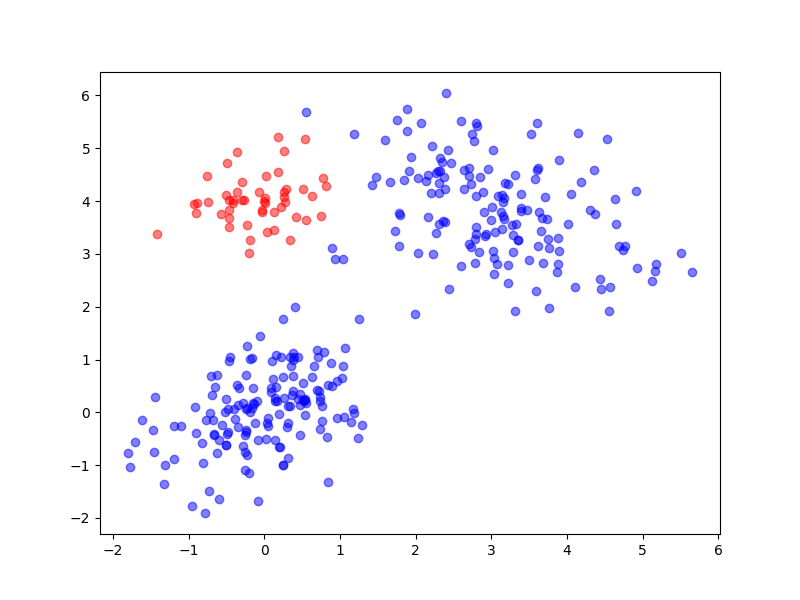

In [11]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pos[:, 0], X_pos[:, 1], c="blue", alpha=0.5)
ax.scatter(X_neg[:, 0], X_neg[:, 1], c="red", alpha=0.5)
# ax.scatter(means[:, 0], means[:, 1], marker='x', s=200, linewidths=3)

# for k in range(K):
#     plot_ellipse(
#         means[k],
#         covs[k],
#         ax,
#         # color=colors[k],
#         alpha=0.8
#     )

In [12]:
# 3) Fit GMM with K=2, using beta=1.0 for repulsion
K = 2
beta = 0.05
pi, means, covs, resp_pos, resp_neg, log_likelihoods = gmm_em_with_negatives(
    X_pos,
    X_neg,
    K=K,
    beta=beta,
    max_iter=50,
    tol=1e-5,
    verbose=True
)

print("\nFinal mixture weights:", pi)
print("Final means:\n", means)
print("Final covariances:\n", covs)
print("Final penalized log-likelihood:", log_likelihoods[-1])

Iteration  0, Penalized LL = -2487.884351
Iteration  1, Penalized LL = -1074.962612
Iteration  2, Penalized LL = -1073.124927
Iteration  3, Penalized LL = -1069.206212
Iteration  4, Penalized LL = -1061.985804
Iteration  5, Penalized LL = -1053.470038
Iteration  6, Penalized LL = -1048.208844
Iteration  7, Penalized LL = -1046.466275
Iteration  8, Penalized LL = -1046.094230
Iteration  9, Penalized LL = -1046.022355
Iteration 10, Penalized LL = -1045.999927
Iteration 11, Penalized LL = -1045.984658
Iteration 12, Penalized LL = -1045.970048
Iteration 13, Penalized LL = -1045.954994
Iteration 14, Penalized LL = -1045.939241
Iteration 15, Penalized LL = -1045.922697
Iteration 16, Penalized LL = -1045.905321
Iteration 17, Penalized LL = -1045.887090
Iteration 18, Penalized LL = -1045.867996
Iteration 19, Penalized LL = -1045.848039
Iteration 20, Penalized LL = -1045.827225
Iteration 21, Penalized LL = -1045.805565
Iteration 22, Penalized LL = -1045.783078
Iteration 23, Penalized LL = -1045

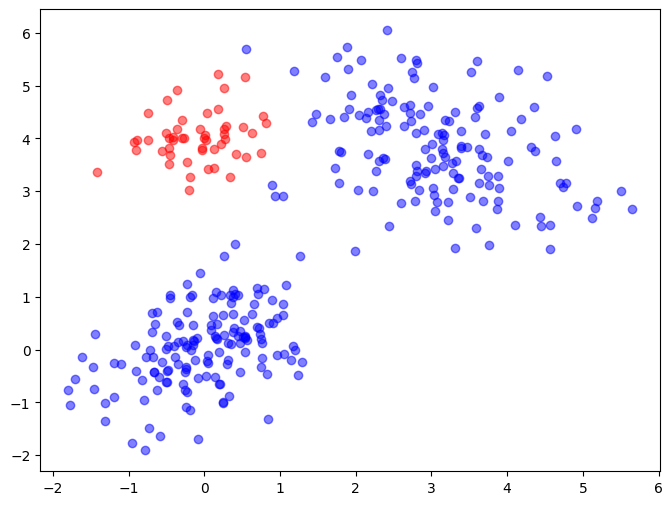

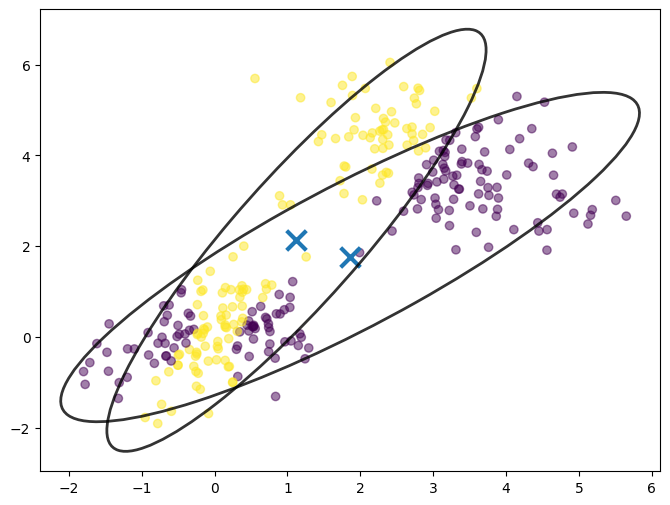

In [13]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pos[:, 0], X_pos[:, 1], c=resp_pos.argmax(axis=1), cmap='viridis', alpha=0.5)
ax.scatter(means[:, 0], means[:, 1], marker='x', s=200, linewidths=3)

for k in range(K):
    plot_ellipse(
        means[k],
        covs[k],
        ax,
        # color=colors[k],
        alpha=0.8
    )

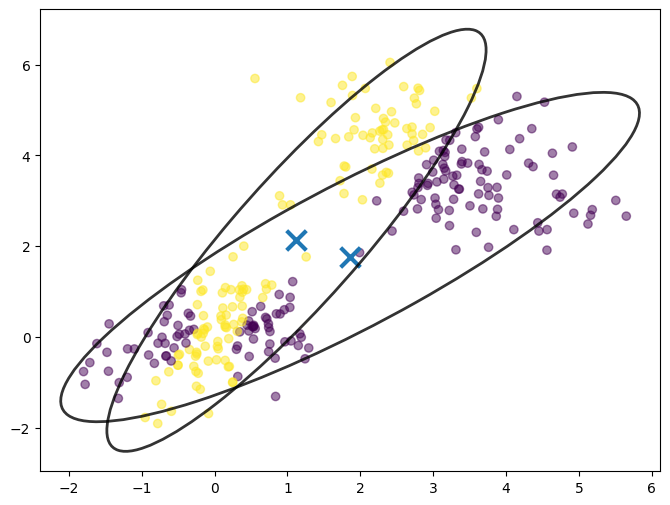

In [14]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pos[:, 0], X_pos[:, 1], c=resp_pos.argmax(axis=1), cmap='viridis', alpha=0.5)
ax.scatter(means[:, 0], means[:, 1], marker='x', s=200, linewidths=3)

for k in range(K):
    plot_ellipse(
        means[k],
        covs[k],
        ax,
        # color=colors[k],
        alpha=0.8
    )